# 1.Reddit GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations
df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/reddit_graph.csv"
)

print("REDDIT_GRAPH DATA")
print(df.shape)

REDDIT_GRAPH DATA
(37585, 30)


In [2]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# 1. GENERATE NODES
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("reddit_node.csv", index=False, encoding='utf-8')

# 2. GENERATE EDGES (REDDIT COMMUNITY & ENGAGEMENT)
edges_list = []

#sorted by followers
sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A.TOPIC & LANGUAGE ---
# Based onTop Feature: Gaming, Education, Food, Entertainment
# and top language: Japanese, Korean, Portuguese
cat_features = ['topic', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Reddit Interest Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            # Increase weight for Gaming and Education (Top 5 importance)
            weight = 1.5 if val in ['Gaming', 'Education'] else 1.2
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": feat
            })

# --- B. WEEKEND VIBE ---
if 'is_weekend' in sorted_df.columns:
    print("Processing Weekend Engagement Homophily...")
    weekend_group = sorted_df[sorted_df['is_weekend'] == 1]
    ids = weekend_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.0, 
                "Relation": "weekend_connection"
            })

# --- C. MEDIA TYPE POLL ---
if 'media_type' in sorted_df.columns:
    print("Processing Reddit Poll Interaction...")
    poll_group = sorted_df[sorted_df['media_type'] == 'Poll']
    ids = poll_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.3, 
                "Relation": "poll_homophily"
            })

# --- D. TOXICITY & NEGATIVE SENTIMENT ---
if 'toxicity_score' in sorted_df.columns:
    print("Processing Reddit Debate & Toxicity Vibe...")
    temp_df = sorted_df.copy()
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.8, 
                "Relation": "toxicity_cluster"
            })

# --- E. USER-ID ---
print("Processing Reddit User Posting History...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.0, 
                "Relation": "same_author"
            })

# 3. CLEAN & EXPORT
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("reddit_edge.csv", index=False, encoding='utf-8')

print(f"\n--- REDDIT GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Processing Reddit Interest Homophily: topic...
Processing Reddit Interest Homophily: language...
Processing Weekend Engagement Homophily...
Processing Reddit Poll Interaction...
Processing Reddit Debate & Toxicity Vibe...
Processing Reddit User Posting History...

--- REDDIT GRAPH ---
Nodes: 37,585
Edges: 126,417
Time: 5.65s


In [3]:
import pandas as pd

graph_df = pd.read_csv(
    "reddit-result-12.csv"
)

print("GRAPH FEATURES DATA")
print(graph_df.shape)
print("\nColumns:")
print(graph_df.columns.tolist())

GRAPH FEATURES DATA
(37585, 45)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Weighted Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'componentnumber', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality']


In [4]:
# SELECT USEFUL GRAPH FEATURES
graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "clustering",
    "modularity_class"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(37585, 6)


In [5]:
original_df = df.copy()

# REMOVE DUPLICATES
original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [6]:
# MERGE POST_ID BACK TO TRAIN/TEST
# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [8]:
# LOAD REDDIT TRAIN / TEST

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print("METADATA DATASETS")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (30068, 56)
Test Shape : (7517, 56)


In [9]:
# MERGE TRAIN
train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# MERGE TEST
test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [10]:
print("\n" + "="*30)
print("TRAIN CLASS DISTRIBUTION")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nProportion %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("TEST CLASS DISTRIBUTION")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nProportion %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


TRAIN CLASS DISTRIBUTION
popularity
0    23931
1     6137
Name: count, dtype: int64

Proportion %:
popularity
0    79.589597
1    20.410403
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
popularity
0    5983
1    1534
Name: count, dtype: int64

Proportion %:
popularity
0    79.592923
1    20.407077
Name: proportion, dtype: float64


In [11]:
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"scale_pos_weight = {ratio:.2f}")

scale_pos_weight = 3.90


In [12]:
# FILL MISSING VALUES 
numeric_graph_cols = [
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "clustering"
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

if "modularity_class" in train_hybrid.columns:
    train_hybrid["modularity_class"] = train_hybrid["modularity_class"].fillna(-1)
    test_hybrid["modularity_class"]  = test_hybrid["modularity_class"].fillna(-1)

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("HYBRID DATASETS")
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")

HYBRID DATASETS
Train Hybrid: (30068, 61)
Test Hybrid : (7517, 61)


In [13]:
for df_tmp in [train_hybrid, test_hybrid]:
    if "modularity_class" in df_tmp.columns:
        df_tmp["modularity_class"] = "comm_" + df_tmp["modularity_class"].astype(str)

categorical_cols = ["topic", "language", "media_type", "sentiment_category", "location", "modularity_class"]

existing_cats = [col for col in categorical_cols if col in train_hybrid.columns]

train_hybrid = pd.get_dummies(train_hybrid, columns=existing_cats, drop_first=True, dtype=int)
test_hybrid = pd.get_dummies(test_hybrid, columns=existing_cats, drop_first=True, dtype=int)

train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=train_cols, fill_value=0)
print(f"Number of features: {train_hybrid.shape[1]}")

Number of features: 116


In [14]:
# SAVE HYBRID DATASETS
train_hybrid.to_csv(
    "reddit_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "reddit_hybrid_test.csv",
    index=False
)

In [15]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [17]:
# LOAD HYBRID DATASETS
train_df = pd.read_csv(
    "reddit_hybrid_train.csv"
)

test_df = pd.read_csv(
    "reddit_hybrid_test.csv"
)

print("HYBRID DATASETS")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (30068, 116)
Test Shape : (7517, 116)


In [18]:
drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [19]:
X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (30068, 113)
X_test Shape : (7517, 113)


In [26]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,        
    max_depth=7,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,      
    random_state=42,            
    n_jobs=-1                   
)

In [27]:
print("TRAINING HYBRID MODEL...")
model.fit(
    X_train,
    y_train
)

TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [28]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [29]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [30]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      5983
           1       0.44      0.75      0.56      1534

    accuracy                           0.76      7517
   macro avg       0.68      0.75      0.69      7517
weighted avg       0.82      0.76      0.78      7517

ROC-AUC  : 0.8413


In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("CONFUSION MATRIX")
print(cm)

CONFUSION MATRIX
[[4546 1437]
 [ 387 1147]]


In [33]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                      feature  importance
82   modularity_class_comm_32    0.078638
66   modularity_class_comm_18    0.068034
77   modularity_class_comm_28    0.058682
67   modularity_class_comm_19    0.057726
3                   followers    0.052064
73   modularity_class_comm_24    0.044477
84   modularity_class_comm_34    0.040491
96   modularity_class_comm_45    0.036334
109   modularity_class_comm_6    0.031186
86   modularity_class_comm_36    0.026823
58   modularity_class_comm_10    0.024819
63   modularity_class_comm_15    0.022926
88   modularity_class_comm_38    0.021980
61   modularity_class_comm_13    0.021186
97   modularity_class_comm_46    0.014892
107  modularity_class_comm_55    0.014565
65   modularity_class_comm_17    0.013809
98   modularity_class_comm_47    0.013062
94   modularity_class_comm_43    0.011063
80   modularity_class_comm_30    0.009858


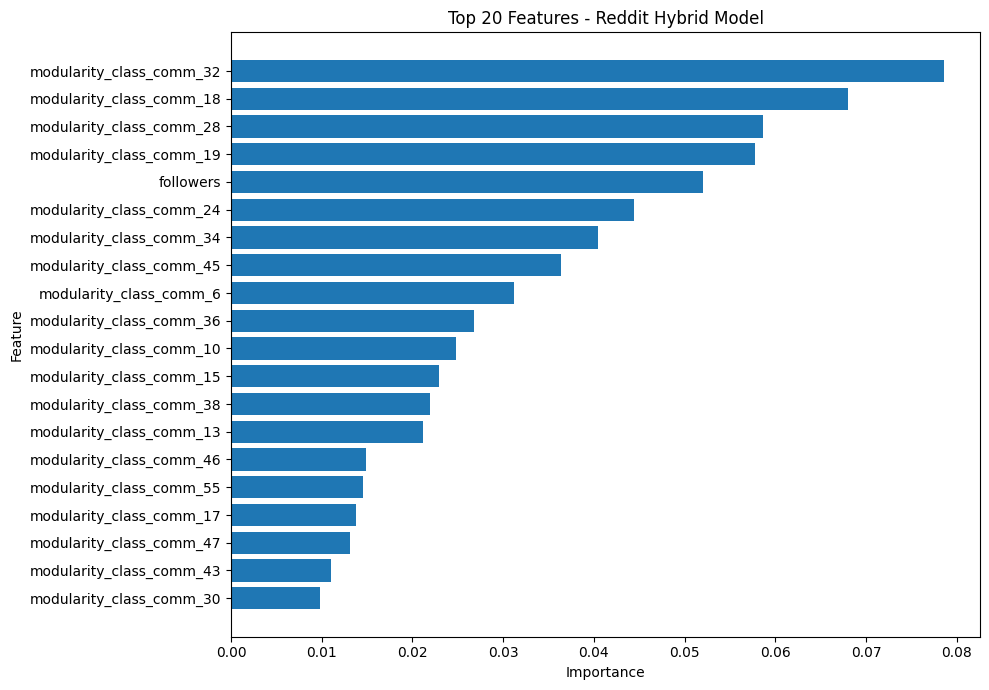

In [35]:
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Reddit Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. Reddit NODE2VEC

 GRAPH EMBEDDING

In [36]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()
edges_df = pd.read_csv("reddit_edge.csv") 

G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

print("TRAINING NODE2VEC (MULTI-CORE)...")
Number_cpu_cores = os.cpu_count()
print(f"Number of CPU cores: {Number_cpu_cores}.")



Graph Created | Nodes: 37,585 | Edges: 116,157
TRAINING NODE2VEC (MULTI-CORE)...
Number of CPU cores: 22.


In [37]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=Number_cpu_cores,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec completed")

print(f"\nNode2Vec completed after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/37585 [00:00<?, ?it/s]


Node2Vec completed

Node2Vec completed after: 15.21 minutes 


In [38]:
node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 

emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('RED')]

emb_df.to_csv("reddit_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} vectors of Post articles")

Successfully saved 37585 vectors of Post articles


In [39]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [40]:
train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print("METADATA DATA")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (30068, 56)
Test Shape : (7517, 56)


In [41]:
embedding_df = pd.read_csv(
    "reddit_node2vec_8dims.csv"
)

print("NODE2VEC EMBEDDINGS")
print(embedding_df.shape)
print("\nEmbedding Columns:")
print(embedding_df.columns[:10])

NODE2VEC EMBEDDINGS
(37585, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [42]:
train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

print("MISSING EMBEDDINGS CHECK")


embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)

MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [43]:
X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("FINAL DATA")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL DATA
X_train: (30068, 61)
X_test : (7517, 61)


In [44]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      
    n_estimators=400,            
    learning_rate=0.03,         
    max_depth=7,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    reg_alpha=0.5,               
    reg_lambda=1.5,              
    random_state=42,
    n_jobs=-1
)


print("TRAINING NODE2VEC HYBRID MODEL...")
model.fit(
    X_train,
    y_train
)

print("Training completed ")

# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

TRAINING NODE2VEC HYBRID MODEL...
Training completed 


In [45]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      5983
           1       0.46      0.72      0.56      1534

    accuracy                           0.77      7517
   macro avg       0.69      0.75      0.70      7517
weighted avg       0.82      0.77      0.79      7517

ROC-AUC  : 0.8387


In [46]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.274105
58                emb_5    0.020638
57                emb_4    0.017624
55                emb_2    0.017196
60                emb_7    0.016914
59                emb_6    0.016846
54                emb_1    0.016471
53                emb_0    0.015257
56                emb_3    0.015143
39    language_Japanese    0.013756
22      topic_Education    0.013607
44      media_type_Poll    0.013545
40      language_Korean    0.013298
18  sentiment_intensity    0.013250
4      account_age_days    0.013242
9    sentiment_negative    0.012790
41  language_Portuguese    0.012779
8    sentiment_positive    0.012692
6        content_length    0.012601
10       toxicity_score    0.012530


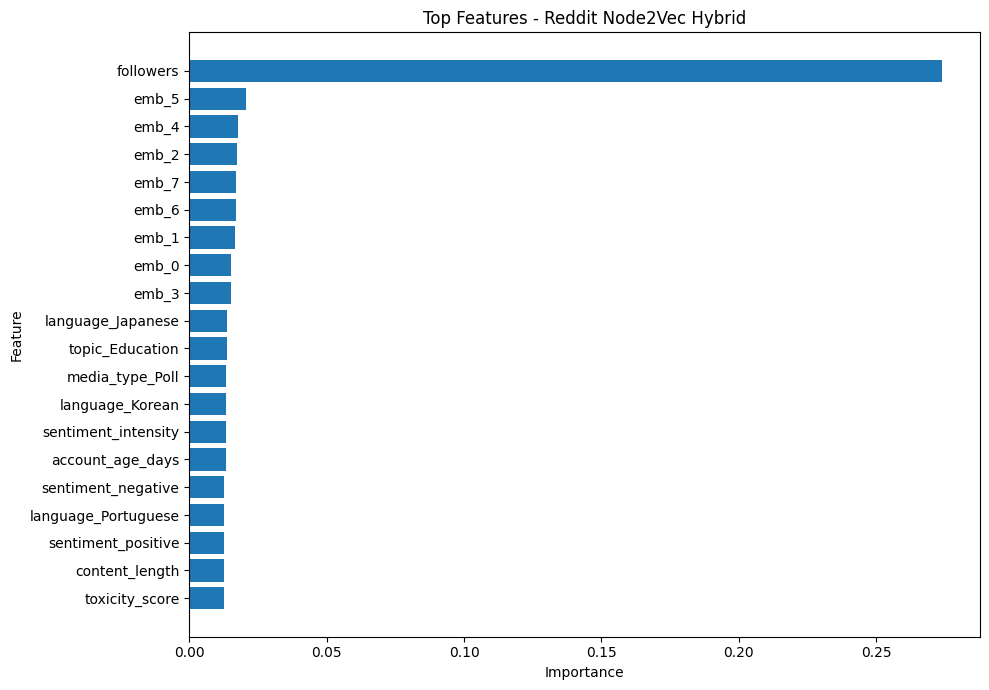

In [47]:
top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Reddit Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Reddit graph + Node2vector

In [48]:
selected_n2v = ["emb_0", "emb_6", "emb_3", "emb_4", "emb_1"]

embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print(f"Selected columns: {embedding_df_filtered.columns.tolist()}")

Selected columns: ['post_id', 'emb_0', 'emb_6', 'emb_3', 'emb_4', 'emb_1']


In [49]:
train_df = pd.read_csv(
    "reddit_hybrid_train.csv"
)

test_df = pd.read_csv(
    "reddit_hybrid_test.csv"
)


print("GRAPH HYBRID DATA")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# LOAD NODE2VEC EMBEDDINGS
print("NODE2VEC EMBEDDINGS")
print(embedding_df.shape)


# CHECK EMBEDDING KEY
print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (30068, 116)
Test Shape : (7517, 116)
NODE2VEC EMBEDDINGS
(37585, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [50]:
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")

Train Shape: (30068, 121) | Test Shape: (7517, 121)


In [51]:
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\nCheck missing {len(actual_emb_cols)} for embedding columns")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values: {train_final[actual_emb_cols].isnull().sum().sum()}")


Check missing 5 for embedding columns
Missing values: 0


In [52]:
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"Final number of features: {train_final.shape[1]}")

Final number of features: 119


In [53]:
X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("FINAL FEATURE SPACE")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

FINAL FEATURE SPACE
X_train: (30068, 118)
X_test : (7517, 118)


In [54]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                   
)


# TRAIN MODEL
print("TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...")
model.fit(
    X_train,
    y_train
)

print("\nTraining completed")

# PREDICTIONS
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

TRAINING FINAL INSTAGRAM META + GRAPH + EMBEDDING...

Training completed


In [55]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [56]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      5983
           1       0.44      0.77      0.56      1534

    accuracy                           0.75      7517
   macro avg       0.68      0.76      0.69      7517
weighted avg       0.83      0.75      0.77      7517

ROC-AUC  : 0.8436


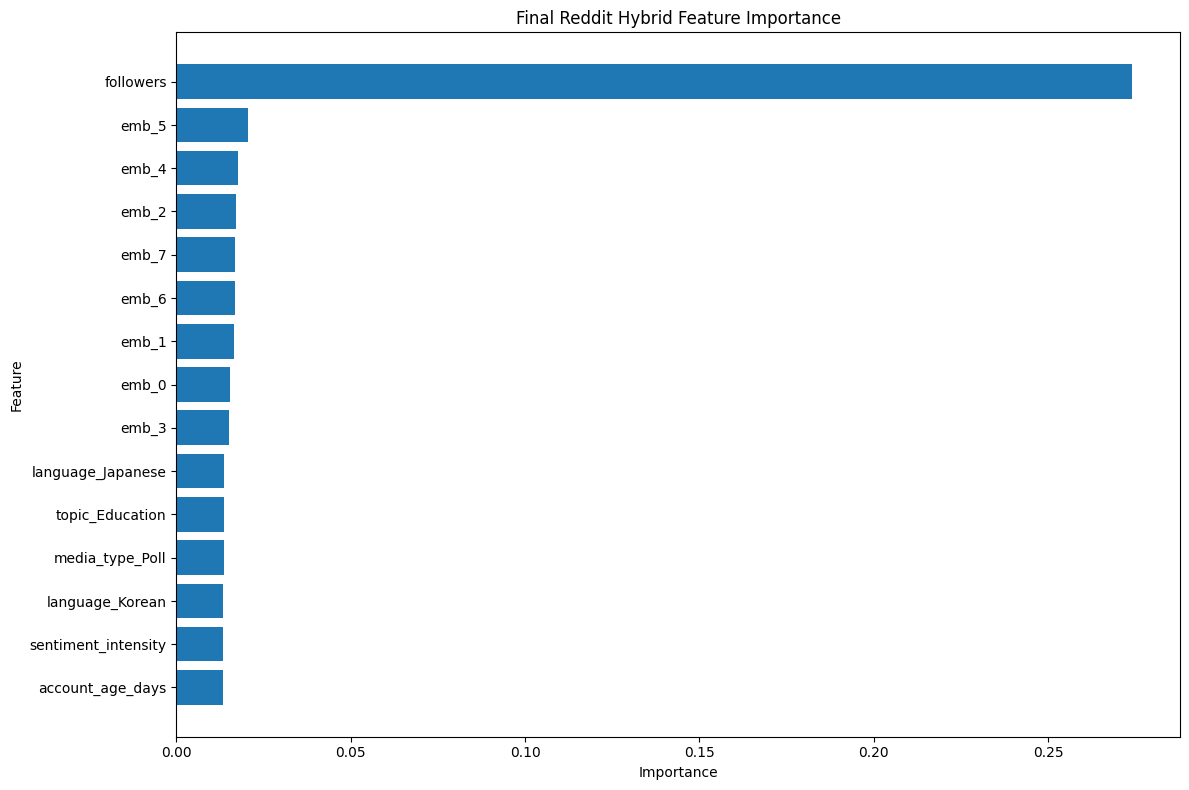

In [57]:
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Reddit Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()